# 🛍️ Retail Sales Prediction and Business Insights Analysis

##  Project Introduction

In today's competitive retail industry, understanding customer purchasing behavior is essential for improving business performance and making data-driven decisions. Retail businesses generate large volumes of transactional data, which can be analyzed to uncover valuable insights about customer demographics, product preferences, and sales trends.

This project performs an end-to-end analysis of a real-world retail sales dataset. The study explores sales patterns through Exploratory Data Analysis (EDA), identifies the key factors influencing sales, and develops a machine learning model to predict the total sales amount based on customer and product information.

By combining statistical analysis, data visualization, and predictive modeling, the project demonstrates how data science techniques can support informed business decision-making in the retail sector.

##  Project Objectives

The objectives of this project are:

- Perform data quality assessment and preprocessing.
- Explore customer purchasing behavior using Exploratory Data Analysis (EDA).
- Identify relationships between customer attributes, product categories, and sales.
- Analyze sales trends using statistical summaries and visualizations.
- Build a Linear Regression model to predict the total purchase amount.
- Evaluate the predictive performance of the model using regression metrics.
- Generate business insights and recommendations based on the analysis.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

In [9]:
df=pd.read_csv("retail_sales_dataset.csv")

In [10]:
df.head(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [11]:
df.tail(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [12]:
df.shape

(1000, 9)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [14]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [16]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

# Dataset Understanding

The retail sales dataset contains transactional information describing customer purchases across multiple product categories. Each record represents a single retail transaction and includes customer demographics, product information, pricing details, and the final purchase amount.

The dataset consists of **1,000 observations** and **9 attributes**, making it suitable for both exploratory analysis and predictive modeling.

---

## Dataset Attributes

| Column | Description |
|---------|-------------|
| Transaction ID | Unique identifier for each transaction |
| Date | Date of purchase |
| Customer ID | Unique customer identifier |
| Gender | Customer gender |
| Age | Customer age |
| Product Category | Purchased product category |
| Quantity | Number of products purchased |
| Price per Unit | Cost of a single product |
| Total Amount | Total transaction value |

---

## Statistical Summary

Descriptive statistics provide an overview of the numerical variables within the dataset.

Key numerical features include:

- Customer Age
- Quantity Purchased
- Price per Unit
- Total Amount

The statistical summary helps identify the central tendency, spread, and potential outliers before proceeding with data preprocessing and analysis.

In [17]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

## Missing Values and Duplicates

Missing values and duplicates can affect the quality of analysis and machine learning models. Therefore, each column was examined for null values.

The dataset contains **no missing values** and **no duplicate records**, indicating that it is complete and suitable for further analysis without requiring imputation techniques.

In [20]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].head()

0   2023-11-24
1   2023-02-27
2   2023-01-13
3   2023-05-21
4   2023-05-06
Name: Date, dtype: datetime64[ns]

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [22]:
df.nunique()

Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
dtype: int64

## Unique Value Analysis

The number of unique values in each column was examined to better understand the diversity of customer demographics, product categories, and transaction information.

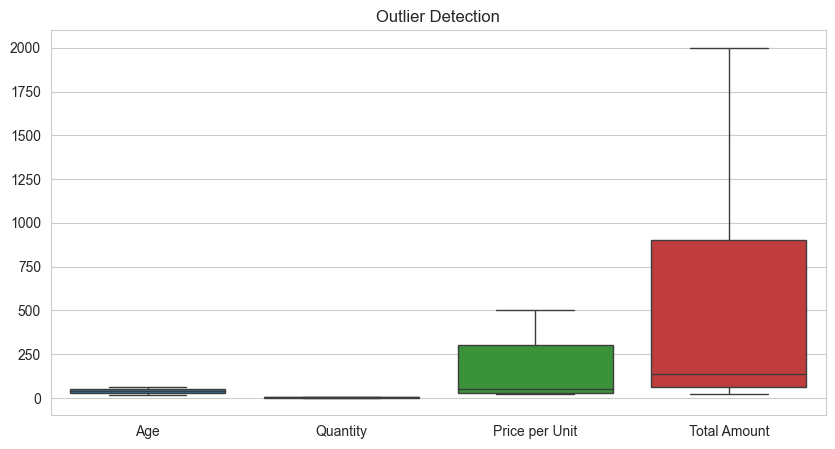

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Age','Quantity','Price per Unit','Total Amount']])
plt.title("Outlier Detection")
plt.show()

# Data Quality Assessment & Preparation

The dataset underwent a comprehensive quality assessment before analysis.

The following preprocessing steps were completed:

- Checked for missing values
- Verified duplicate records
- Confirmed data types
- Converted the Date column into datetime format
- Examined unique values
- Inspected numerical features for potential outliers

The assessment confirmed that the dataset is clean, consistent, and suitable for exploratory data analysis and predictive modeling.

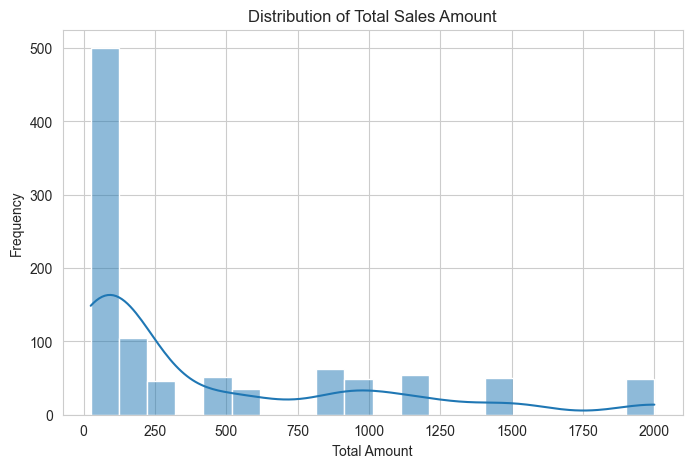

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Amount'], bins=20, kde=True)
plt.title("Distribution of Total Sales Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

## Total Sales Distribution

The distribution of transaction amounts provides an overview of customer spending patterns.

The histogram indicates how frequently different purchase amounts occur, helping identify whether customer spending is concentrated around particular price ranges or spread across a wider range.

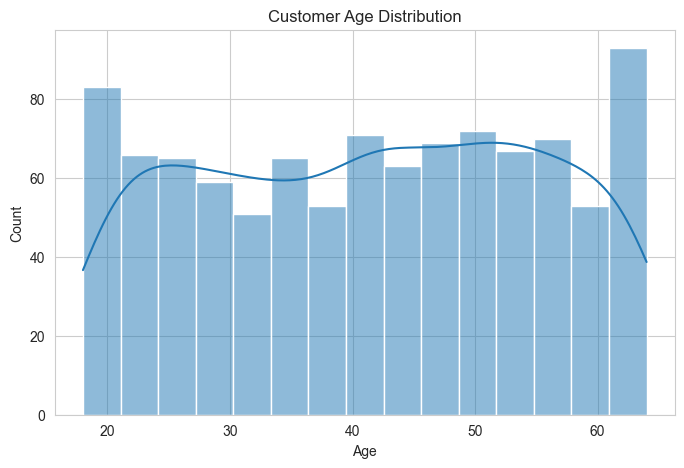

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Customer Age Distribution

The age distribution illustrates the demographic composition of customers.

Understanding customer age groups enables businesses to better target marketing campaigns and product offerings.

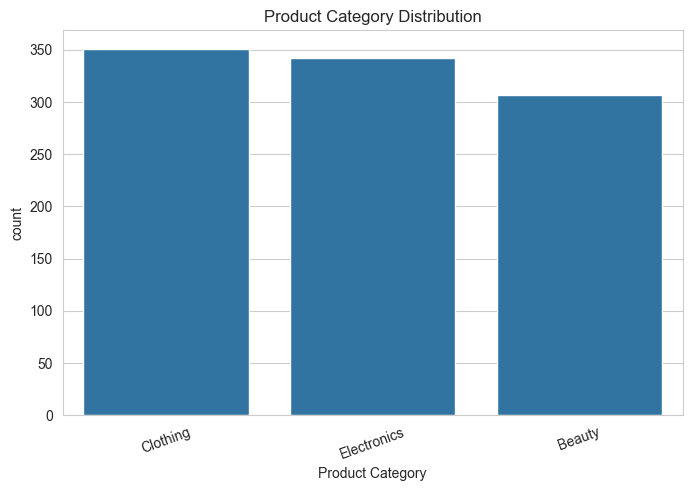

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='Product Category',
              order=df['Product Category'].value_counts().index)

plt.title("Product Category Distribution")
plt.xticks(rotation=20)

plt.show()

### Product Category Distribution

The distribution of product categories shows the frequency of purchases across different retail segments.

This visualization helps identify the most frequently purchased product categories within the dataset.

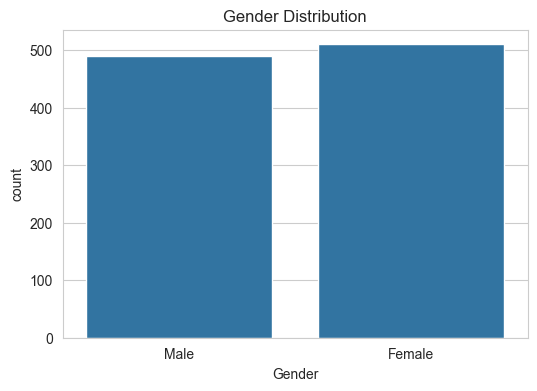

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x='Gender')

plt.title("Gender Distribution")

plt.show()

### Gender Distribution

The gender distribution provides insight into the composition of customers included in the dataset and helps determine whether purchasing behavior varies across genders.

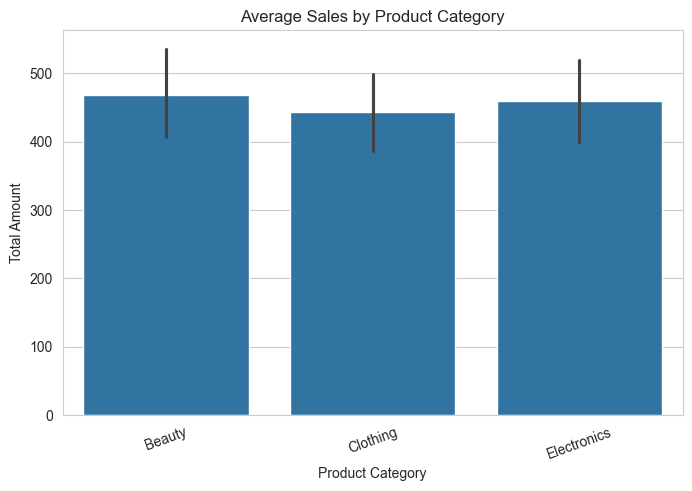

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(data=df,
            x='Product Category',
            y='Total Amount',
            estimator='mean')

plt.title("Average Sales by Product Category")
plt.xticks(rotation=20)

plt.show()

## Product Category vs Sales

Average sales were compared across product categories to determine which categories generate the highest transaction values.

This analysis provides valuable insight into customer purchasing preferences and revenue contribution.

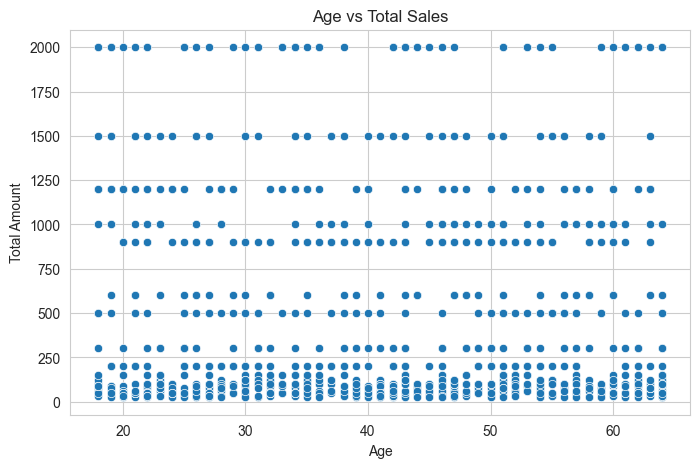

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x='Age',
                y='Total Amount')

plt.title("Age vs Total Sales")

plt.show()

### Age vs Total Sales

The scatter plot explores the relationship between customer age and transaction amount.

The analysis helps determine whether customer age influences purchasing behaviour.

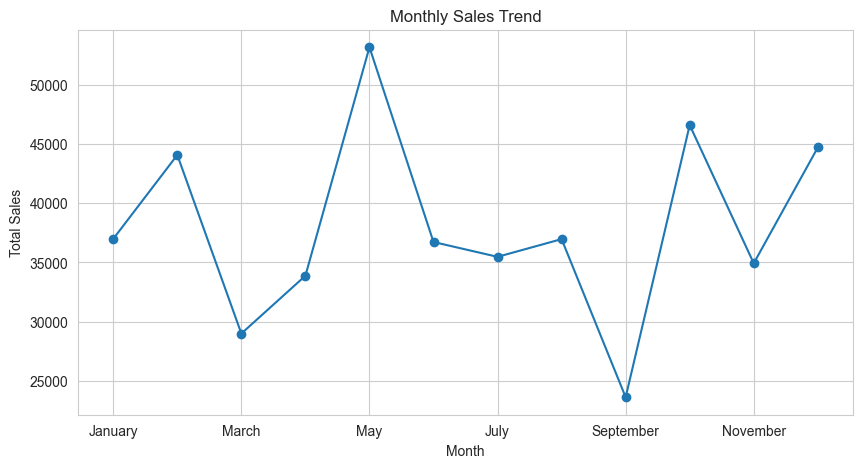

In [33]:
df['Month'] = df['Date'].dt.month_name()

monthly_sales = df.groupby('Month')['Total Amount'].sum()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

## Monthly Sales Trend

Monthly sales trends reveal seasonal purchasing patterns and fluctuations in customer demand over time.

Businesses can use this information for inventory management, promotional planning, and sales forecasting.

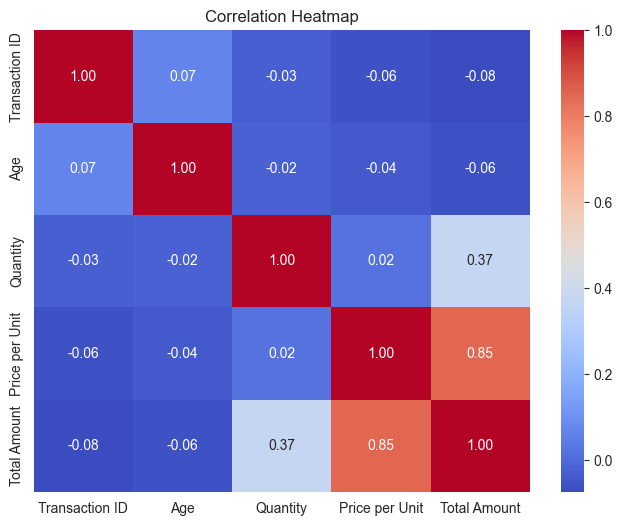

In [34]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

# Exploratory Data Analysis Summary

Exploratory Data Analysis (EDA) was conducted to understand customer purchasing behaviour and identify patterns within the retail sales dataset.

The analysis included:

- Distribution of numerical variables
- Customer demographic analysis
- Product category analysis
- Sales comparison across customer groups
- Monthly sales trend analysis
- Correlation analysis

The findings from EDA provide valuable insights into customer behaviour and establish a strong foundation for predictive modelling.

In [36]:
X = df[['Age', 'Quantity', 'Price per Unit']]
y = df['Total Amount']

## Feature Selection

The following numerical features were selected for model training:

- Age
- Quantity Purchased
- Price per Unit

The target variable is:

- Total Amount

These variables are expected to influence the overall transaction value and provide a strong basis for prediction.

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 800
Testing Samples : 200


## Data Splitting

The dataset was divided into training and testing sets using an 80:20 ratio.

- Training Set: 80%
- Testing Set: 20%

This approach allows the model to learn from historical data while evaluating its performance on unseen observations.

In [38]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred = model.predict(X_test)

In [41]:
prediction_df = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

prediction_df.head(10)

,Actual Sales,Predicted Sales
521,1500,1339.959109
737,100,46.081705
740,300,481.772051
660,100,340.327460
411,2000,1543.931177
678,90,196.710650
626,50,-147.943935
513,300,508.898673
859,200,385.305066
136,1000,1160.401000


## Prediction Results

The table above compares the actual transaction amounts with the values predicted by the Linear Regression model.

A close agreement between the two indicates effective predictive performance.

The sales prediction model was successfully developed using Linear Regression.

The model was trained on historical retail transaction data and generated predictions for unseen records. The next phase evaluates the model's performance using regression metrics and visualization techniques.

# Model Evaluation

After training the Linear Regression model, its predictive performance was evaluated using standard regression metrics.

The evaluation measures how closely the predicted sales values match the actual transaction amounts in the testing dataset.

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [44]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 173.11610215441945
Mean Squared Error (MSE): 41896.213221343605
Root Mean Squared Error (RMSE): 204.68564488342508
R² Score: 0.856877226425043


- The model achieved an **R² score of 0.857**, indicating that approximately **85.7% of the variation in total sales** is explained by the selected input features.
- The **Mean Absolute Error (MAE)** of **173.12** suggests that the model's predictions differ from the actual sales by an average of approximately 173 units.
- The **Root Mean Squared Error (RMSE)** of **204.69** indicates relatively low prediction error, demonstrating good model accuracy.

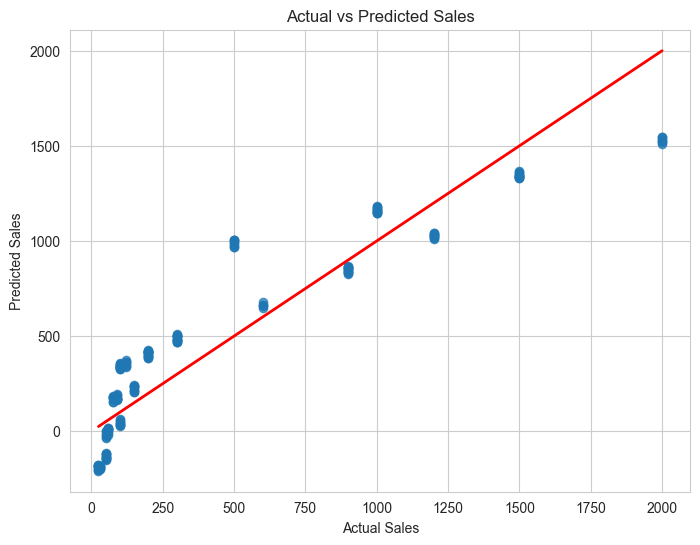

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## Actual vs Predicted Sales

The scatter plot compares the actual sales values with those predicted by the Linear Regression model.

If the model performs well, the points will align closely with the diagonal reference line, indicating that predicted values closely match the actual observations.

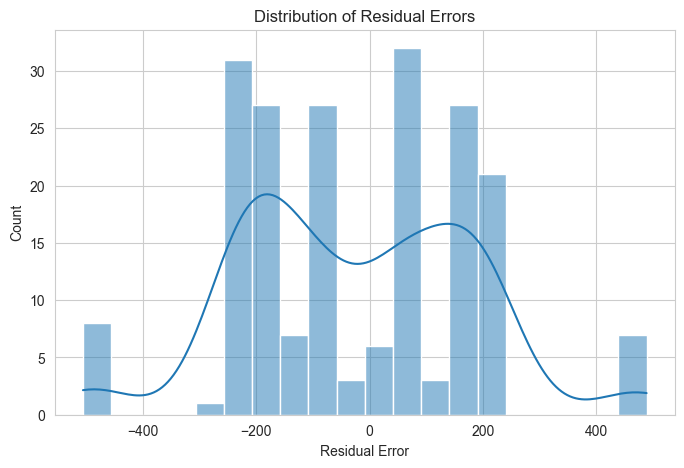

In [46]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=20, kde=True)

plt.title("Distribution of Residual Errors")
plt.xlabel("Residual Error")

plt.show()

## Residual Analysis

Residuals represent the difference between the actual and predicted sales values.

A residual distribution centered around zero suggests that the model produces unbiased predictions and captures the underlying relationship effectively.

## Model Performance Summary

The Linear Regression model demonstrated strong predictive capability for estimating retail sales.

Key observations:

- The model achieved a high R² score, indicating that it successfully explains most of the variation in the target variable.
- Low prediction errors (MAE, MSE, and RMSE) suggest accurate sales estimation.
- The Actual vs Predicted plot shows close agreement between observed and predicted values.
- Residual analysis indicates that prediction errors are relatively small and randomly distributed.

Overall, the model is effective for predicting retail sales using customer demographics and purchasing information.

### BUSINESS INSIGHTS

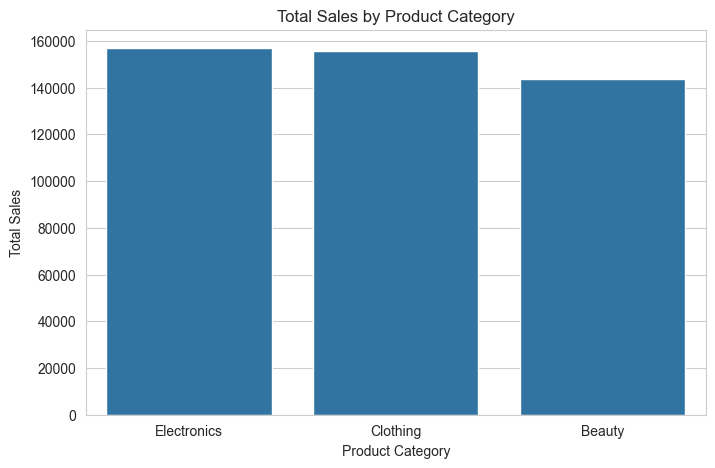

In [47]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.show()

## Product Category Performance

Product category analysis highlights the contribution of each category to overall revenue.

Identifying high-performing categories enables businesses to optimize inventory management, promotional campaigns, and product placement.

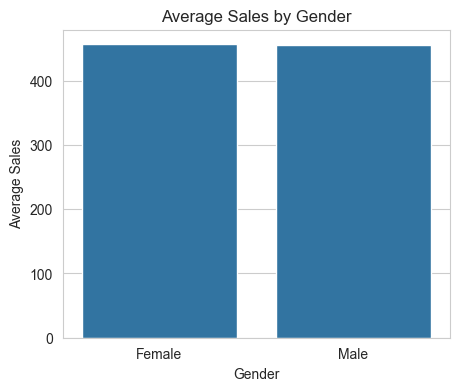

In [48]:
gender_sales = df.groupby('Gender')['Total Amount'].mean()

plt.figure(figsize=(5,4))

sns.barplot(
    x=gender_sales.index,
    y=gender_sales.values
)

plt.title("Average Sales by Gender")
plt.ylabel("Average Sales")

plt.show()

## Customer Spending by Gender

Average purchase amounts were compared across customer genders.

Understanding spending behavior helps businesses design targeted marketing campaigns and personalized customer experiences.

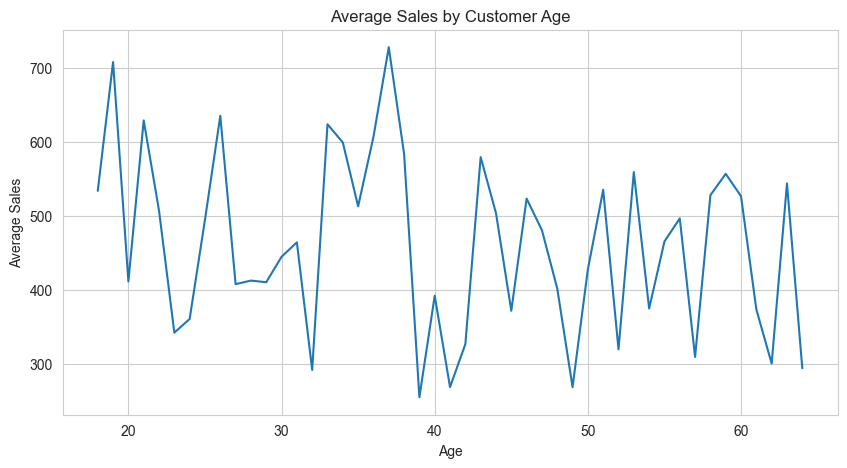

In [49]:
age_sales = df.groupby('Age')['Total Amount'].mean()

plt.figure(figsize=(10,5))

plt.plot(age_sales.index, age_sales.values)

plt.title("Average Sales by Customer Age")
plt.xlabel("Age")
plt.ylabel("Average Sales")

plt.show()

## Customer Age Analysis

Customer spending varies across different age groups.

This analysis helps retailers identify valuable customer segments and develop age-specific promotional strategies.

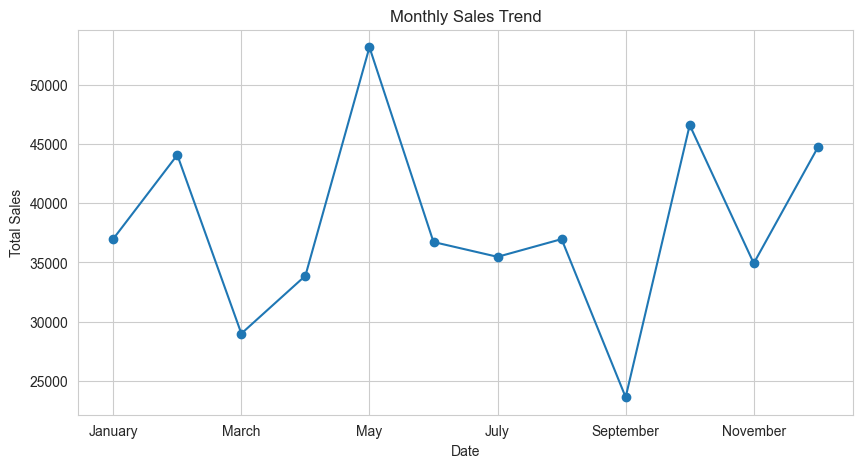

In [50]:
monthly_sales = df.groupby(df['Date'].dt.month_name())['Total Amount'].sum()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.ylabel("Total Sales")

plt.show()

## Monthly Sales Trends

Monthly sales analysis helps businesses identify periods of high and low customer demand.

Such trends can support inventory planning, staffing decisions, and seasonal marketing campaigns.

## Business Recommendations

Based on the analysis, the following recommendations are proposed:

- Prioritize inventory for high-performing product categories to maximize revenue.
- Develop targeted marketing campaigns for customer segments with higher purchasing potential.
- Utilize seasonal sales trends for inventory and promotional planning.
- Continue collecting high-quality transactional data to improve future predictive models.
- Integrate predictive analytics into retail operations to support demand forecasting and strategic decision-making.

# 12. Conclusion

This project successfully demonstrated an end-to-end data analytics workflow using a real-world retail sales dataset. Beginning with data understanding and quality assessment, the dataset was explored through comprehensive exploratory data analysis to identify customer purchasing patterns, sales trends, and relationships among key variables.

A Linear Regression model was then developed to predict the total sales amount based on customer demographics and purchasing information. The model achieved an **R² Score of approximately 0.857**, indicating that it explained nearly **85.7% of the variation in retail sales**, demonstrating strong predictive performance.

The analysis also generated valuable business insights regarding customer behavior, product category performance, and purchasing trends. These findings can support retailers in making informed decisions related to inventory management, customer segmentation, and sales forecasting.

Overall, this project highlights the practical application of data science techniques in solving real-world retail problems and demonstrates the complete workflow from raw data to actionable business recommendations.